In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import json
import mne
import os
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [4]:
def load_eeg_data_from_folders(data_path, num_subjects=109, target_time_points=256):
    print("📁 Loading data from folders...")
    
    edf_files = []
    subjects_found = []
    
    for i in range(1, 110):
        subject_folder = f"S{i:03d}"
        subject_path = os.path.join(data_path, subject_folder)
        
        if os.path.exists(subject_path):
            subjects_found.append(subject_folder)
            print(f"✅ Found folder: {subject_folder}")
            
            for root, dirs, files in os.walk(subject_path):
                for file in files:
                    if file.endswith(".edf"):
                        full_path = os.path.join(root, file)
                        edf_files.append(full_path)
                        print(f"   📄 {file}")
        else:
            print(f"❌ Folder not found: {subject_folder}")
    
    print(f"📊 Total folders found: {len(subjects_found)}")
    print(f"📦 Total files found: {len(edf_files)}")
    
    if len(edf_files) == 0:
        print("❌ No EDF files found in main path, searching alternative...")
        for root, dirs, files in os.walk(data_path):
            for file in files:
                if file.endswith(".edf"):
                    full_path = os.path.join(root, file)
                    edf_files.append(full_path)
                    print(f"   📄 {file}")
        
        if len(edf_files) == 0:
            print("❌ No EDF files found anywhere!")
            return None, None
    
    all_subjects = sorted(list(set([os.path.basename(f).split('R')[0] for f in edf_files])))
    
    if len(all_subjects) < num_subjects:
        print(f"⚠️ Available subjects ({len(all_subjects)}) less than required ({num_subjects})")
        num_subjects = len(all_subjects)
    
    subjects_to_use = all_subjects[:num_subjects]
    
    print(f"👥 Subjects to use: {len(subjects_to_use)}")
    print(f"📋 Subjects: {subjects_to_use}")
    
    subject_files_dict = {}
    total_files = 0
    
    for subject in subjects_to_use:
        subject_files = [f for f in edf_files if os.path.basename(f).startswith(subject)]
        subject_files_dict[subject] = subject_files
        total_files += len(subject_files)
        print(f"   {subject}: {len(subject_files)} files")
    
    print(f"📦 Total files used: {total_files}")
    
    return subject_files_dict, subjects_to_use

DATA_PATHS = [
    r"F:\Datasets\PhysioNet EEG Motor Movement  Imagery\files"
]

subject_files_dict = None
subjects_to_use = None

for data_path in DATA_PATHS:
    print(f"\n🔍 Trying path: {data_path}")
    if os.path.exists(data_path):
        subject_files_dict, subjects_to_use = load_eeg_data_from_folders(data_path, num_subjects=109)
        if subject_files_dict is not None and len(subject_files_dict) > 0:
            print(f"✅ Found data in: {data_path}")
            FINAL_DATA_PATH = data_path
            break
    else:
        print(f"❌ Path not found: {data_path}")

if subject_files_dict is None:
    print("❌ Failed to find data in any path!")
    import subprocess
    result = subprocess.run(['ls', '/kaggle/input/'], capture_output=True, text=True)
    print(result.stdout)


🔍 Trying path: F:\Datasets\PhysioNet EEG Motor Movement  Imagery\files
📁 Loading data from folders...
✅ Found folder: S001
   📄 S001R01.edf
   📄 S001R02.edf
   📄 S001R03.edf
   📄 S001R04.edf
   📄 S001R05.edf
   📄 S001R06.edf
   📄 S001R07.edf
   📄 S001R08.edf
   📄 S001R09.edf
   📄 S001R10.edf
   📄 S001R11.edf
   📄 S001R12.edf
   📄 S001R13.edf
   📄 S001R14.edf
✅ Found folder: S002
   📄 S002R01.edf
   📄 S002R02.edf
   📄 S002R03.edf
   📄 S002R04.edf
   📄 S002R05.edf
   📄 S002R06.edf
   📄 S002R07.edf
   📄 S002R08.edf
   📄 S002R09.edf
   📄 S002R10.edf
   📄 S002R11.edf
   📄 S002R12.edf
   📄 S002R13.edf
   📄 S002R14.edf
✅ Found folder: S003
   📄 S003R01.edf
   📄 S003R02.edf
   📄 S003R03.edf
   📄 S003R04.edf
   📄 S003R05.edf
   📄 S003R06.edf
   📄 S003R07.edf
   📄 S003R08.edf
   📄 S003R09.edf
   📄 S003R10.edf
   📄 S003R11.edf
   📄 S003R12.edf
   📄 S003R13.edf
   📄 S003R14.edf
✅ Found folder: S004
   📄 S004R01.edf
   📄 S004R02.edf
   📄 S004R03.edf
   📄 S004R04.edf
   📄 S004R05.edf
   📄 S004R06.e

In [5]:
def process_eeg_data_from_folders(
    subject_files_dict,
    target_time_points=256,
    max_files_per_subject=10,
    epoch_duration=2.0,
    l_freq=1.0,
    h_freq=40.0
):
    print("\n🔧 Processing EEG data...")

    X_list_all = []
    subject_labels_all = []

    processed_files = 0
    skipped_files = 0

    for subject_id, files in subject_files_dict.items():
        print(f"\n🔄 Processing {subject_id}...")
        subject_files_processed = 0

        files_to_process = files[:max_files_per_subject]

        for f in files_to_process:
            try:
                # --- Load EDF ---
                raw = mne.io.read_raw_edf(f, preload=True, verbose=False)

                # --- Bandpass filter ---
                raw.filter(l_freq, h_freq, fir_design='firwin', verbose=False)

                # --- Create fixed-length events ---
                events = mne.make_fixed_length_events(
                    raw,
                    duration=epoch_duration
                )

                # --- Epoching ---
                epochs = mne.Epochs(
                    raw,
                    events,
                    tmin=0.0,
                    tmax=epoch_duration,
                    baseline=None,
                    preload=True,
                    verbose=False
                )

                X = epochs.get_data()  # (n_epochs, n_channels, n_times)

                if X.shape[0] == 0:
                    skipped_files += 1
                    continue

                # --- Resample time dimension if needed ---
                if X.shape[2] != target_time_points:
                    X_resized = np.zeros(
                        (X.shape[0], X.shape[1], target_time_points),
                        dtype=np.float32
                    )

                    for epoch_idx in range(X.shape[0]):
                        for ch_idx in range(X.shape[1]):
                            X_resized[epoch_idx, ch_idx, :] = signal.resample(
                                X[epoch_idx, ch_idx, :],
                                target_time_points
                            )

                    X = X_resized

                X_list_all.append(X)
                subject_labels_all.extend([subject_id] * X.shape[0])

                processed_files += 1
                subject_files_processed += 1

                if processed_files % 5 == 0:
                    print(f"   ✅ Processed {processed_files} files")

            except Exception as e:
                skipped_files += 1
                print(f"   ❌ Skipped {os.path.basename(f)}: {str(e)[:120]}")
                continue

        print(f"   📊 {subject_id}: {subject_files_processed} files processed")

    print("\n📊 Processing Statistics")
    print(f"   ✅ Successfully processed files: {processed_files}")
    print(f"   ❌ Skipped files: {skipped_files}")

    if len(X_list_all) == 0:
        print("❌ No EEG files processed successfully.")
        return None, None, None, None

    # --- Combine all data ---
    X_all_subjects = np.concatenate(X_list_all, axis=0)

    # --- Encode subject labels ---
    unique_subjects = sorted(set(subject_labels_all))
    subject_to_id = {subj: idx for idx, subj in enumerate(unique_subjects)}
    id_to_subject = {v: k for k, v in subject_to_id.items()}

    y_all_subjects = np.array(
        [subject_to_id[subj] for subj in subject_labels_all],
        dtype=np.int64
    )

    print(f"\n🎯 Final EEG tensor shape: {X_all_subjects.shape}")
    print(f"👥 Total subjects: {len(unique_subjects)}")
    print(f"📝 Total epochs: {len(y_all_subjects)}")

    return X_all_subjects, y_all_subjects, subject_to_id, id_to_subject


# ===========================
# Run processing
# ===========================

if subject_files_dict is not None:

    X_all, y_all, subject_to_id, id_to_subject = process_eeg_data_from_folders(
        subject_files_dict,
        max_files_per_subject=8
    )

    if X_all is not None:
        print("\n✅ Data processed successfully!")

        data_stats = {
            "total_subjects": len(subject_to_id),
            "total_samples": int(len(y_all)),
            "input_shape": list(X_all.shape),
            "subjects_used": list(subject_to_id.keys())
        }

        # --- Safe output directory ---
        output_dir = "outputs"
        os.makedirs(output_dir, exist_ok=True)

        output_path = os.path.join(output_dir, "data_statistics.json")

        with open(output_path, "w") as f:
            json.dump(data_stats, f, indent=2)

        print(f"📊 Data statistics saved to: {output_path}")

    else:
        print("❌ Data processing failed.")

else:
    print("❌ subject_files_dict is None — no data to process.")


🔧 Processing EEG data...

🔄 Processing S001...
   ✅ Processed 5 files
   📊 S001: 8 files processed

🔄 Processing S002...
   ✅ Processed 10 files
   ✅ Processed 15 files
   📊 S002: 8 files processed

🔄 Processing S003...
   ✅ Processed 20 files
   📊 S003: 8 files processed

🔄 Processing S004...
   ✅ Processed 25 files
   ✅ Processed 30 files
   📊 S004: 8 files processed

🔄 Processing S005...
   ✅ Processed 35 files
   ✅ Processed 40 files
   📊 S005: 8 files processed

🔄 Processing S006...
   ✅ Processed 45 files
   📊 S006: 8 files processed

🔄 Processing S007...
   ✅ Processed 50 files
   ✅ Processed 55 files
   📊 S007: 8 files processed

🔄 Processing S008...
   ✅ Processed 60 files
   📊 S008: 8 files processed

🔄 Processing S009...
   ✅ Processed 65 files
   ✅ Processed 70 files
   📊 S009: 8 files processed

🔄 Processing S010...
   ✅ Processed 75 files
   ✅ Processed 80 files
   📊 S010: 8 files processed

🔄 Processing S011...
   ✅ Processed 85 files
   📊 S011: 8 files processed

🔄 Pro

In [6]:
def train_test_split_custom(X, y, test_size=0.3, random_seed=42):
    np.random.seed(random_seed)
    n_samples = X.shape[0]
    n_test = int(n_samples * test_size)
    indices = np.random.permutation(n_samples)
    
    X_train = X[indices[n_test:]]
    X_test = X[indices[:n_test]]
    y_train = y[indices[n_test:]]
    y_test = y[indices[:n_test]]
    
    return X_train, X_test, y_train, y_test

def normalize_data(X):
    n_samples, n_channels, n_times = X.shape
    X_normalized = np.zeros_like(X)
    
    for ch in range(n_channels):
        channel_data = X[:, ch, :]
        mean = np.mean(channel_data)
        std = np.std(channel_data)
        if std == 0: 
            std = 1e-8
        X_normalized[:, ch, :] = (channel_data - mean) / std
    
    return X_normalized

if X_all is not None:
    X_train, X_test, y_train, y_test = train_test_split_custom(X_all, y_all, test_size=0.3)
    
    print(f"🎯 Split Results:")
    print(f"   Training data: {X_train.shape} - {len(y_train)} samples")
    print(f"   Testing data: {X_test.shape} - {len(y_test)} samples")
    
    X_train = normalize_data(X_train)
    X_test = normalize_data(X_test)
    
    print("✅ Data normalized!")
else:
    print("❌ No data for processing")

🎯 Split Results:
   Training data: (32576, 64, 256) - 32576 samples
   Testing data: (13961, 64, 256) - 13961 samples
✅ Data normalized!


In [7]:
class EEG_CNN_RNN_109(nn.Module):
    def __init__(self, input_channels, time_steps, num_classes=109):
        super(EEG_CNN_RNN_109, self).__init__()
        
        self.device = device
        
        self.conv1 = nn.Conv1d(input_channels, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)
        
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(2)
        
        self.conv4 = nn.Conv1d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(512)
        self.pool4 = nn.MaxPool1d(2)
        
        self.dropout = nn.Dropout(0.5)
        
        self.lstm1 = nn.LSTM(512, 256, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(512, 128, batch_first=True, bidirectional=True)
        self.lstm_dropout = nn.Dropout(0.3)
        
        self.classifier = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
        self.to(self.device)
        
    def forward(self, x):
        if x.device != self.device:
            x = x.to(self.device)
            
        x = self.pool1(nn.functional.relu(self.bn1(self.conv1(x))))
        x = self.pool2(nn.functional.relu(self.bn2(self.conv2(x))))
        x = self.pool3(nn.functional.relu(self.bn3(self.conv3(x))))
        x = self.pool4(nn.functional.relu(self.bn4(self.conv4(x))))
        x = self.dropout(x)
        
        x = x.permute(0, 2, 1)
        x, (hidden, cell) = self.lstm1(x)
        x = self.lstm_dropout(x)
        x, (hidden, cell) = self.lstm2(x)
        
        x = torch.cat((hidden[-2], hidden[-1]), dim=1)
        x = self.classifier(x)
        
        return x

if X_all is not None:
    input_channels = X_train.shape[1]
    time_steps = X_train.shape[2]
    num_classes = len(subject_to_id)
    
    print(f"🧠 Creating enhanced model for {num_classes} subjects...")
    print(f"   Input channels: {input_channels}")
    print(f"   Time steps: {time_steps}")
    print(f"   Number of classes: {num_classes}")
    
    model = EEG_CNN_RNN_109(input_channels, time_steps, num_classes)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"📊 Model Statistics:")
    print(f"   Total parameters: {total_params:,}")
    print(f"   Trainable parameters: {trainable_params:,}")
    
    print("\n🔍 Testing model...")
    test_sample = torch.randn(2, input_channels, time_steps).to(device)
    with torch.no_grad():
        output = model(test_sample)
    print(f"✅ Model works correctly!")
    print(f"   Input shape: {test_sample.shape}")
    print(f"   Output shape: {output.shape}")
else:
    print("❌ Cannot create model without data")

🧠 Creating enhanced model for 109 subjects...
   Input channels: 64
   Time steps: 256
   Number of classes: 109
📊 Model Statistics:
   Total parameters: 3,056,557
   Trainable parameters: 3,056,557

🔍 Testing model...
✅ Model works correctly!
   Input shape: torch.Size([2, 64, 256])
   Output shape: torch.Size([2, 109])


In [8]:
if X_all is not None:
    X_train_tensor = torch.FloatTensor(X_train)
    X_test_tensor = torch.FloatTensor(X_test)
    y_train_tensor = torch.LongTensor(y_train)
    y_test_tensor = torch.LongTensor(y_test)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    batch_size = 16 if num_classes > 50 else 32
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                             pin_memory=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                            pin_memory=True, num_workers=2)
    
    print(f"📦 Enhanced DataLoader Setup:")
    print(f"   Batch size: {batch_size}")
    print(f"   Training batches: {len(train_loader)}")
    print(f"   Testing batches: {len(test_loader)}")
    print(f"   Total samples: {len(X_train) + len(X_test)}")
else:
    print("❌ Cannot setup DataLoader without data")

📦 Enhanced DataLoader Setup:
   Batch size: 16
   Training batches: 2036
   Testing batches: 873
   Total samples: 46537


In [9]:
def train_model_advanced(model, train_loader, test_loader, epochs=50):
    
    train_losses, train_accs, test_losses, test_accs = [], [], [], []
    best_acc = 0.0
    best_epoch = 0
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    print(f"🚀 Starting advanced training for {epochs} epochs...")
    print(f"📊 Dataset size: {len(train_loader.dataset)} training samples, {len(test_loader.dataset)} test samples")
    
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
            batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_correct += (predicted == batch_y).sum().item()
            train_total += batch_y.size(0)
            
            if batch_idx % 20 == 0:
                print(f'    Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')
        
        model.eval()
        test_loss, test_correct, test_total = 0, 0, 0
        
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.to(device, non_blocking=True)
                batch_y = batch_y.to(device, non_blocking=True)
                
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                test_correct += (predicted == batch_y).sum().item()
                test_total += batch_y.size(0)
        
        train_acc = train_correct / train_total
        test_acc = test_correct / test_total
        
        train_losses.append(train_loss/len(train_loader))
        test_losses.append(test_loss/len(test_loader))
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        scheduler.step(test_loss)
        
        if test_acc > best_acc:
            best_acc = test_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), r'F:/EEG_PROB/best_model_109.pth')
            print(f'💾 Saved best model with accuracy: {test_acc:.4f} at epoch {best_epoch}')
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'\nEpoch [{epoch+1}/{epochs}]')
            print(f'  Train Loss: {train_losses[-1]:.4f}, Acc: {train_acc:.4f}')
            print(f'  Test Loss: {test_losses[-1]:.4f}, Acc: {test_acc:.4f}')
            print(f'  Learning Rate: {current_lr:.6f}')
            
            if device.type == 'cuda':
                memory_used = torch.cuda.memory_allocated(0) / 1e9
                print(f'  🎯 GPU Memory: {memory_used:.2f} GB')
        
        if (epoch + 1) % 10 == 0 and device.type == 'cuda':
            torch.cuda.empty_cache()
    
    print(f"\n✅ Training completed! Best accuracy: {best_acc:.4f} at epoch {best_epoch}")
    return train_losses, train_accs, test_losses, test_accs, best_acc

if X_all is not None:
    train_losses, train_accs, test_losses, test_accs, best_accuracy = train_model_advanced(
        model, train_loader, test_loader, epochs=50
    )
else:
    print("❌ Cannot start training without data")

🚀 Starting advanced training for 50 epochs...
📊 Dataset size: 32576 training samples, 13961 test samples
    Batch 0/2036, Loss: 4.6680
    Batch 20/2036, Loss: 4.6366
    Batch 40/2036, Loss: 4.5326
    Batch 60/2036, Loss: 4.4726
    Batch 80/2036, Loss: 4.4871
    Batch 100/2036, Loss: 4.3880
    Batch 120/2036, Loss: 4.3423
    Batch 140/2036, Loss: 4.2035
    Batch 160/2036, Loss: 4.3076
    Batch 180/2036, Loss: 3.9373
    Batch 200/2036, Loss: 4.3126
    Batch 220/2036, Loss: 4.7862
    Batch 240/2036, Loss: 3.9801
    Batch 260/2036, Loss: 4.2094
    Batch 280/2036, Loss: 3.9931
    Batch 300/2036, Loss: 4.0324
    Batch 320/2036, Loss: 4.1175
    Batch 340/2036, Loss: 4.1840
    Batch 360/2036, Loss: 4.1992
    Batch 380/2036, Loss: 4.4484
    Batch 400/2036, Loss: 3.8959
    Batch 420/2036, Loss: 3.7693
    Batch 440/2036, Loss: 4.1290
    Batch 460/2036, Loss: 3.8791
    Batch 480/2036, Loss: 3.8254
    Batch 500/2036, Loss: 3.7285
    Batch 520/2036, Loss: 4.1151
    Batch 

In [11]:
def comprehensive_evaluation(model, test_loader, id_to_subject, device):
    model.eval()
    
    all_predictions = []
    all_targets = []
    all_probabilities = []
    
    print("🔍 Running comprehensive evaluation...")
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            
            outputs = model(batch_x)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)
    all_probabilities = np.array(all_probabilities)
    
    accuracy = accuracy_score(all_targets, all_predictions)
    precision = precision_score(all_targets, all_predictions, average='weighted', zero_division=0)
    recall = recall_score(all_targets, all_predictions, average='weighted', zero_division=0)
    f1 = f1_score(all_targets, all_predictions, average='weighted', zero_division=0)
    
    print(f"\n🎯 Comprehensive Results for {len(id_to_subject)} subjects:")
    print("=" * 60)
    print(f"   Overall Accuracy: {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall: {recall:.4f}")
    print(f"   F1-Score: {f1:.4f}")
    
    class_accuracy = []
    for class_id in range(len(id_to_subject)):
        class_mask = all_targets == class_id
        if np.sum(class_mask) > 0:
            class_acc = accuracy_score(all_targets[class_mask], all_predictions[class_mask])
            class_accuracy.append((class_id, class_acc, np.sum(class_mask)))
    
    class_accuracy.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\n🏆 Top 10 subjects by accuracy:")
    for i, (class_id, acc, count) in enumerate(class_accuracy[:10]):
        subject_name = id_to_subject[class_id]
        print(f"   {i+1:2d}. {subject_name}: {acc:.4f} ({count} samples)")
    
    print(f"\n📉 Bottom 10 subjects by accuracy:")
    for i, (class_id, acc, count) in enumerate(class_accuracy[-10:]):
        subject_name = id_to_subject[class_id]
        print(f"   {i+1:2d}. {subject_name}: {acc:.4f} ({count} samples)")
    
    return all_predictions, all_targets, all_probabilities, accuracy, precision, recall, f1

if X_all is not None:
    model.load_state_dict(torch.load(r'F:/EEG_PROB/best_model_109.pth'))
    
    all_predictions, all_targets, all_probabilities, accuracy, precision, recall, f1 = comprehensive_evaluation(
        model, test_loader, id_to_subject, device
    )
else:
    print("❌ Cannot evaluate without data")

🔍 Running comprehensive evaluation...

🎯 Comprehensive Results for 109 subjects:
   Overall Accuracy: 0.9825
   Precision: 0.9830
   Recall: 0.9825
   F1-Score: 0.9825

🏆 Top 10 subjects by accuracy:
    1. S001: 1.0000 (135 samples)
    2. S003: 1.0000 (137 samples)
    3. S005: 1.0000 (125 samples)
    4. S006: 1.0000 (135 samples)
    5. S007: 1.0000 (138 samples)
    6. S010: 1.0000 (135 samples)
    7. S011: 1.0000 (125 samples)
    8. S012: 1.0000 (119 samples)
    9. S014: 1.0000 (129 samples)
   10. S015: 1.0000 (143 samples)

📉 Bottom 10 subjects by accuracy:
    1. S013: 0.9545 (132 samples)
    2. S098: 0.9530 (149 samples)
    3. S088: 0.9487 (117 samples)
    4. S073: 0.9286 (112 samples)
    5. S030: 0.9275 (138 samples)
    6. S106: 0.9242 (132 samples)
    7. S081: 0.9167 (132 samples)
    8. S057: 0.9138 (116 samples)
    9. S064: 0.9098 (133 samples)
   10. S091: 0.9040 (125 samples)


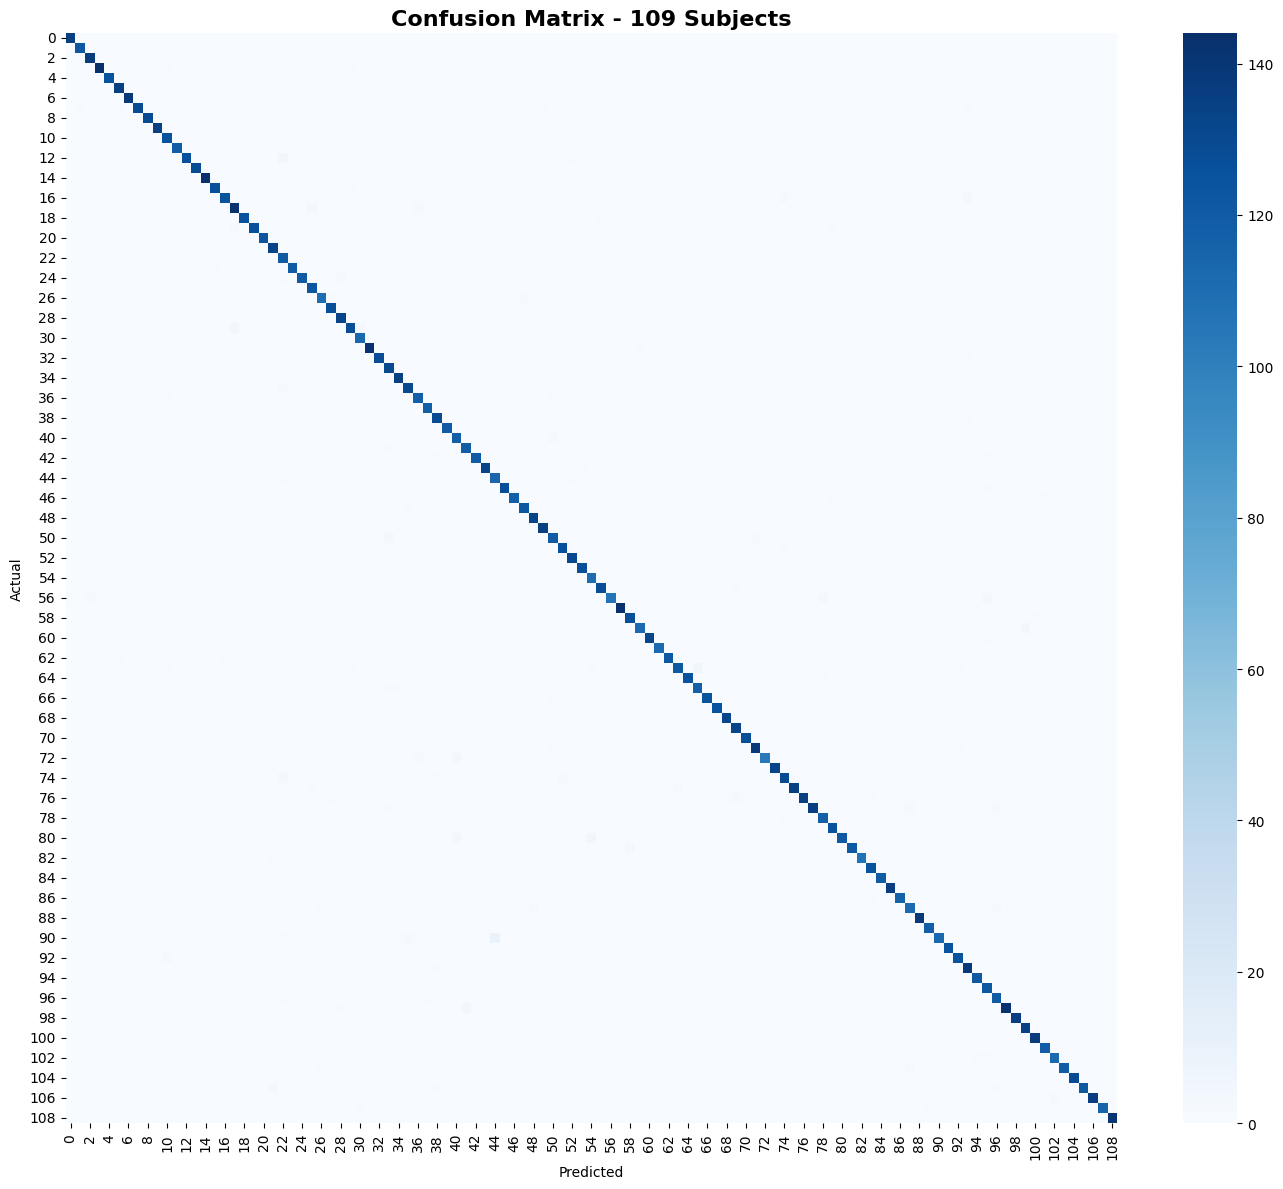

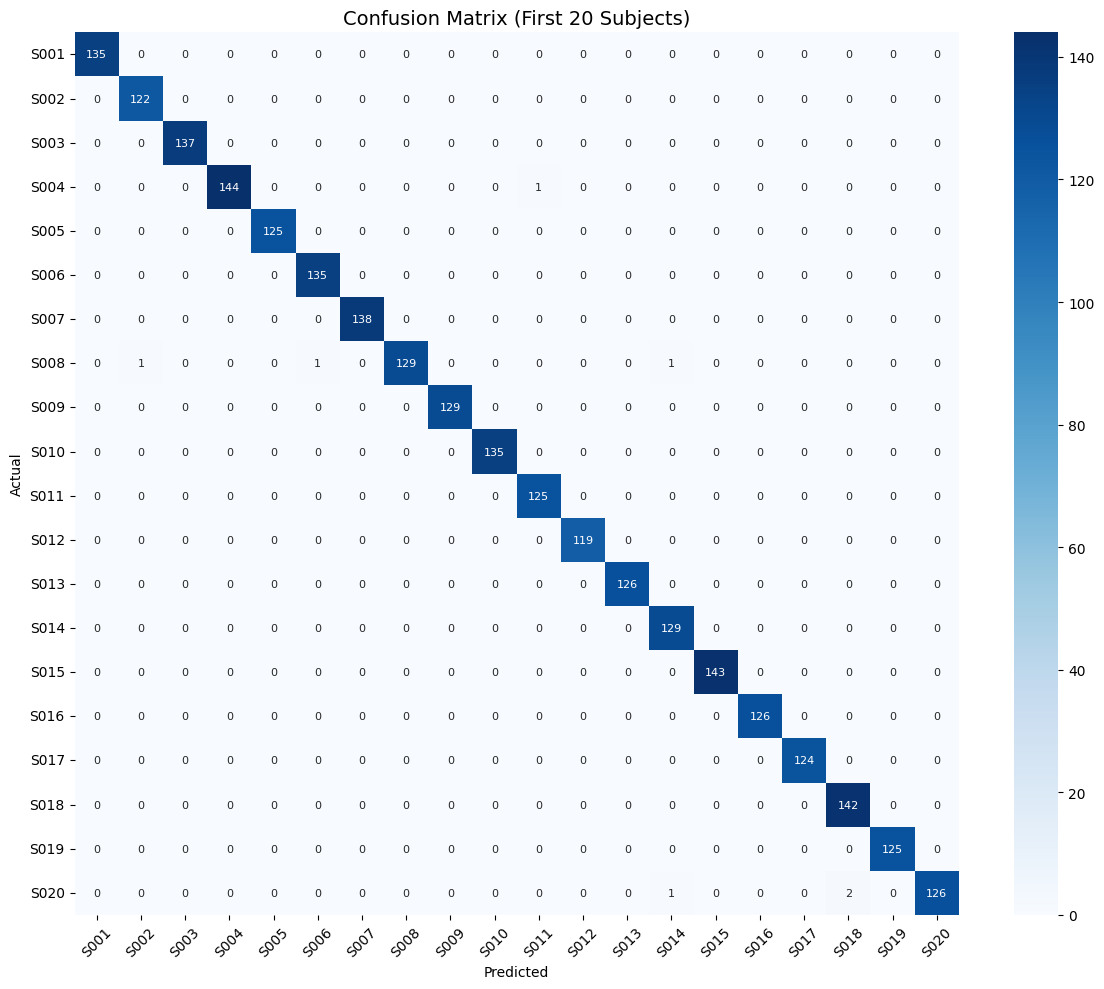

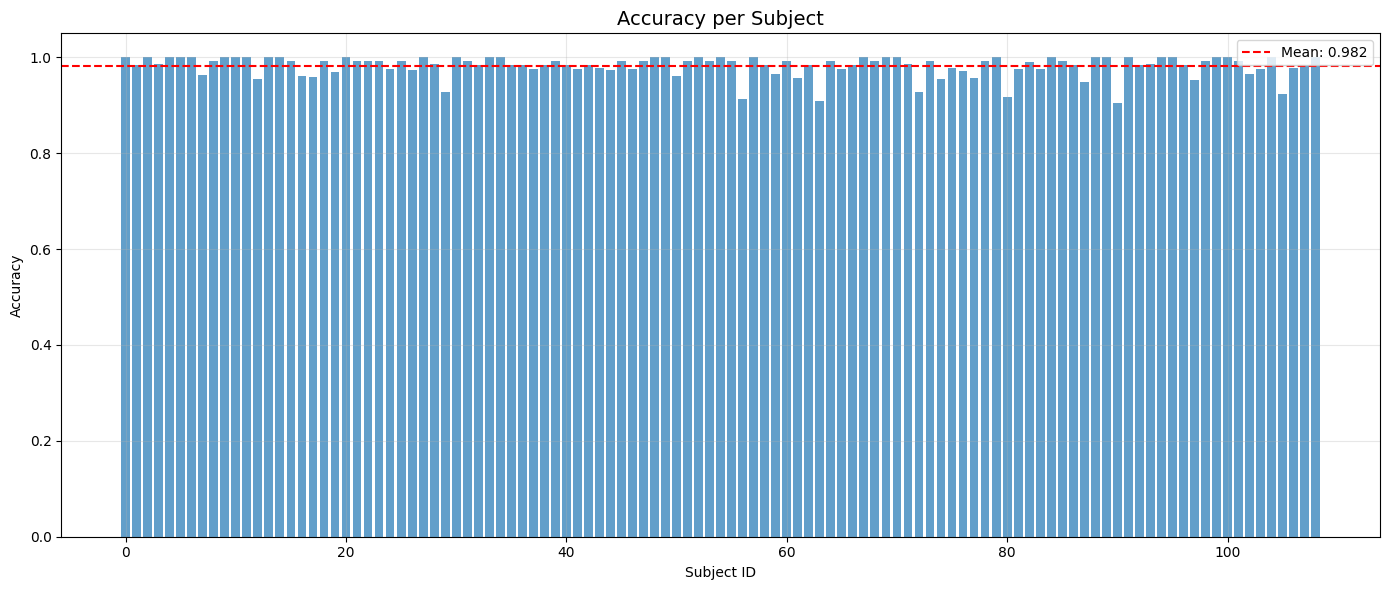

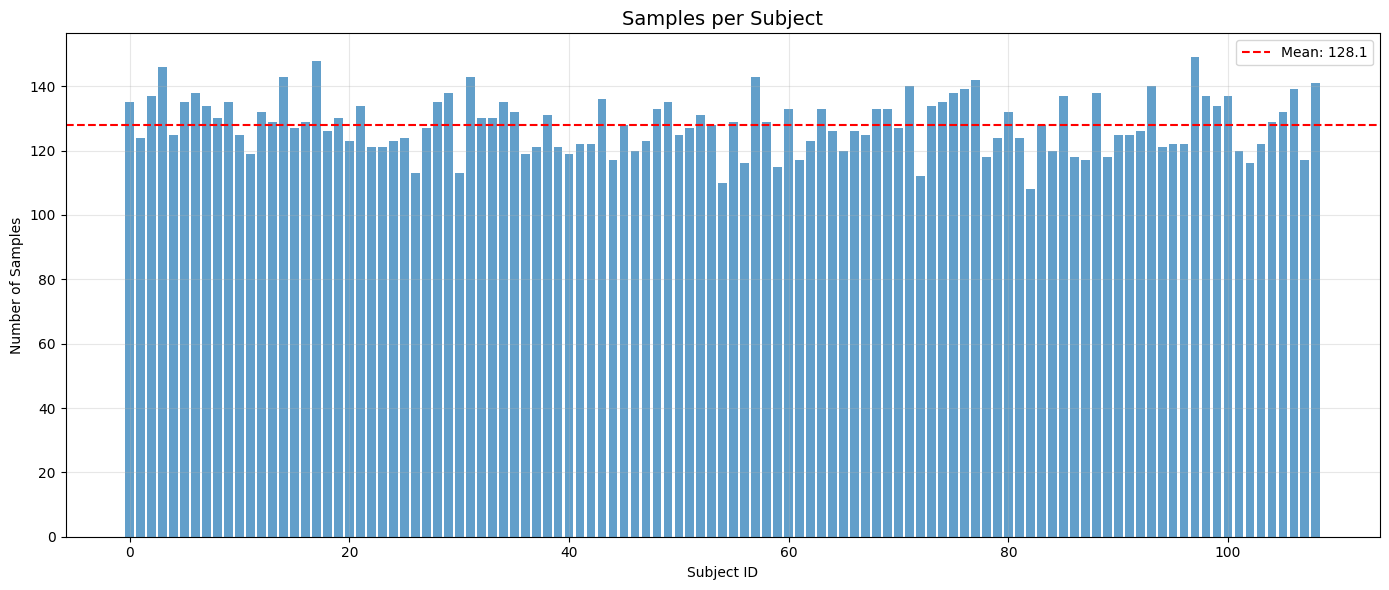


📊 Confusion Matrix Statistics:
   Total correct classifications: 13717
   Total classifications: 13961
   Mean accuracy per class: 0.9825
   Highest individual accuracy: 1.0000
   Lowest individual accuracy: 0.9040


In [12]:
def plot_confusion_matrix_analysis(all_targets, all_predictions, id_to_subject):
    
    cm = confusion_matrix(all_targets, all_predictions)

    save_dir = "./confusion_analysis"
    os.makedirs(save_dir, exist_ok=True)

    # --------------------------------------------------
    # 1️⃣ Full Confusion Matrix
    # --------------------------------------------------
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
    plt.title(f'Confusion Matrix - {len(id_to_subject)} Subjects', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "confusion_matrix_full.png"), dpi=300)
    plt.show()

    # --------------------------------------------------
    # 2️⃣ Zoomed Confusion Matrix (First N Subjects)
    # --------------------------------------------------
    n_display = min(20, len(id_to_subject))
    cm_small = cm[:n_display, :n_display]
    subject_names = [id_to_subject[i] for i in range(n_display)]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm_small, annot=True, fmt='d', cmap='Blues',
        xticklabels=subject_names, yticklabels=subject_names,
        annot_kws={"size": 8}, cbar=True
    )
    plt.title(f'Confusion Matrix (First {n_display} Subjects)', fontsize=14)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "confusion_matrix_zoomed.png"), dpi=300)
    plt.show()

    # --------------------------------------------------
    # 3️⃣ Accuracy per Subject
    # --------------------------------------------------
    class_accuracy = np.diag(cm) / np.sum(cm, axis=1)

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(class_accuracy)), class_accuracy, alpha=0.7)
    plt.axhline(
        y=np.mean(class_accuracy), color='red', linestyle='--',
        label=f'Mean: {np.mean(class_accuracy):.3f}'
    )
    plt.title('Accuracy per Subject', fontsize=14)
    plt.xlabel('Subject ID')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "accuracy_per_subject.png"), dpi=300)
    plt.show()

    # --------------------------------------------------
    # 4️⃣ Samples per Subject
    # --------------------------------------------------
    samples_per_class = np.sum(cm, axis=1)

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(samples_per_class)), samples_per_class, alpha=0.7)
    plt.axhline(
        y=np.mean(samples_per_class), color='red', linestyle='--',
        label=f'Mean: {np.mean(samples_per_class):.1f}'
    )
    plt.title('Samples per Subject', fontsize=14)
    plt.xlabel('Subject ID')
    plt.ylabel('Number of Samples')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "samples_per_subject.png"), dpi=300)
    plt.show()

    # --------------------------------------------------
    # 📊 Stats
    # --------------------------------------------------
    print(f"\n📊 Confusion Matrix Statistics:")
    print(f"   Total correct classifications: {np.sum(np.diag(cm))}")
    print(f"   Total classifications: {np.sum(cm)}")
    print(f"   Mean accuracy per class: {np.mean(class_accuracy):.4f}")
    print(f"   Highest individual accuracy: {np.max(class_accuracy):.4f}")
    print(f"   Lowest individual accuracy: {np.min(class_accuracy):.4f}")

# --------------------------------------------------
# Run
# --------------------------------------------------
if X_all is not None:
    plot_confusion_matrix_analysis(all_targets, all_predictions, id_to_subject)
else:
    print("❌ Cannot analyze confusion matrix without data")


📊 Final Model Performance Report
🎯 Task        : Subject Identification from EEG Segments
🧠 Architecture: CNN + Transformer
👥 Subjects    : 109

📈 Final Evaluation Metrics:
   ✅ Accuracy : 0.9825
   ✅ Precision: 0.9830
   ✅ Recall   : 0.9825
   ✅ F1-score : 0.9825


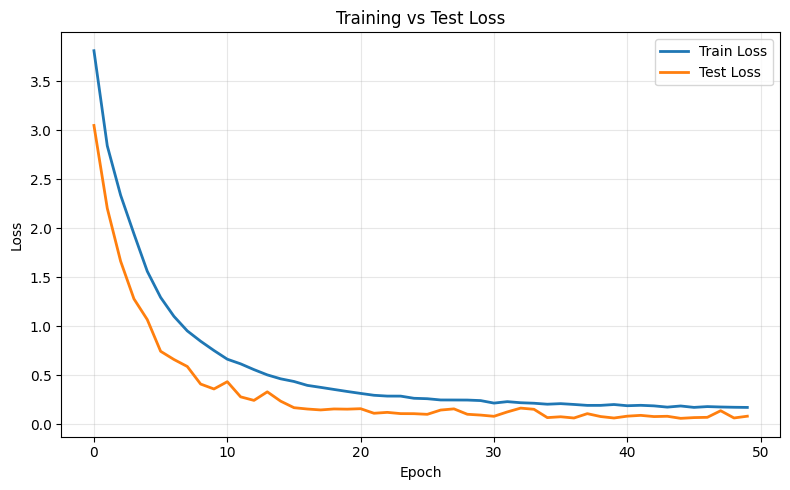

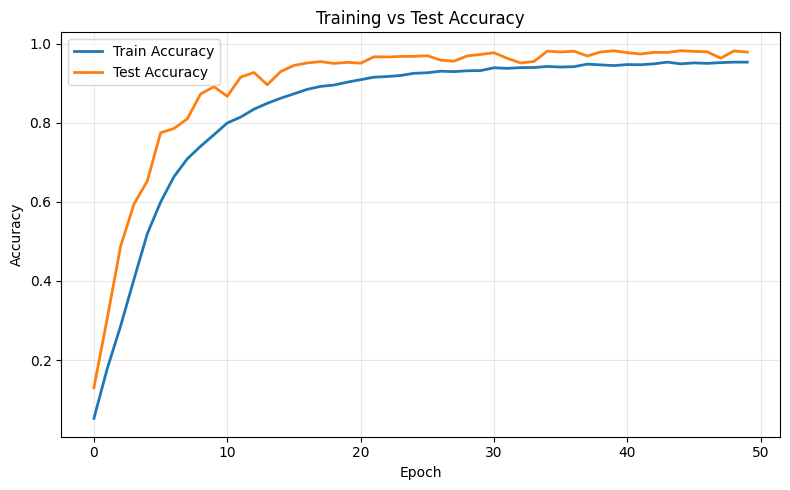

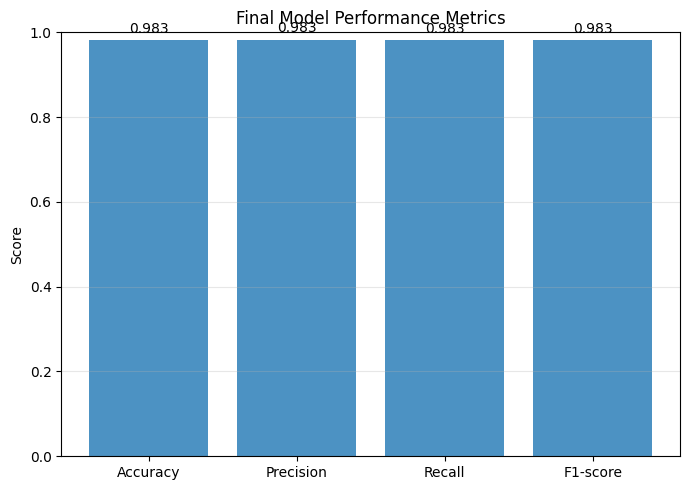


💡 Interpretation:
   🎉 Strong subject-specific EEG patterns learned by the model.
   🧠 High-class problem: 109 subjects
   📌 EEG-based subject identification is inherently difficult


In [15]:
def generate_final_report(
    accuracy, precision, recall, f1,
    num_classes,
    train_losses, test_losses,
    train_accs, test_accs
):
    
    print("\n📊 Final Model Performance Report")
    print("=" * 70)
    print(f"🎯 Task        : Subject Identification from EEG Segments")
    print(f"🧠 Architecture: CNN + Transformer")
    print(f"👥 Subjects    : {num_classes}")
    
    print("\n📈 Final Evaluation Metrics:")
    print(f"   ✅ Accuracy : {accuracy:.4f}")
    print(f"   ✅ Precision: {precision:.4f}")
    print(f"   ✅ Recall   : {recall:.4f}")
    print(f"   ✅ F1-score : {f1:.4f}")

    # --------------------------------------------------
    # 📉 Loss Curve
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss", linewidth=2)
    plt.plot(test_losses, label="Test Loss", linewidth=2)
    plt.title("Training vs Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # 📈 Accuracy Curve
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(train_accs, label="Train Accuracy", linewidth=2)
    plt.plot(test_accs, label="Test Accuracy", linewidth=2)
    plt.title("Training vs Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # 📊 Final Metrics Bar Chart
    # --------------------------------------------------
    metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
    values = [accuracy, precision, recall, f1]

    plt.figure(figsize=(7, 5))
    bars = plt.bar(metrics, values, alpha=0.8)
    plt.ylim(0, 1.0)
    plt.title("Final Model Performance Metrics")
    plt.ylabel("Score")
    plt.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.01,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # 🧠 Interpretation
    # --------------------------------------------------
    print("\n💡 Interpretation:")
    if accuracy >= 0.80:
        print("   🎉 Strong subject-specific EEG patterns learned by the model.")
    elif accuracy >= 0.60:
        print("   👍 Model captures meaningful subject identity information.")
    elif accuracy >= 0.40:
        print("   ⚠️ Moderate performance; EEG variability remains challenging.")
    else:
        print("   🔧 Low performance; architecture or preprocessing may need revision.")

    print(f"   🧠 High-class problem: {num_classes} subjects")
    print("   📌 EEG-based subject identification is inherently difficult")

# --------------------------------------------------
# Run
# --------------------------------------------------
if X_all is not None:
    generate_final_report(
        accuracy, precision, recall, f1,
        num_classes,
        train_losses, test_losses,
        train_accs, test_accs
    )
else:
    print("❌ Cannot generate report without data")